--- Dataset Shape ---
(365, 8)

--- Column Data Types & Null Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              365 non-null    datetime64[ns]
 1   Customer_ID       365 non-null    int64         
 2   Age               365 non-null    int64         
 3   Gender            365 non-null    object        
 4   Product_Category  365 non-null    object        
 5   Quantity          365 non-null    int64         
 6   Price_per_Unit    365 non-null    float64       
 7   Total_Sales       365 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 22.9+ KB
None

--- Descriptive Statistics ---
                                Date  Customer_ID         Age    Quantity  \
count                            365   365.000000  365.000000  365.000000   
mean   2023

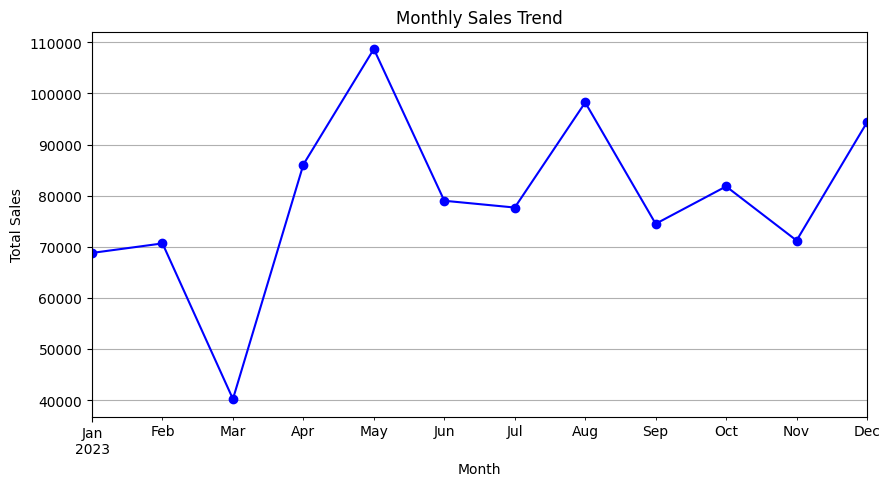

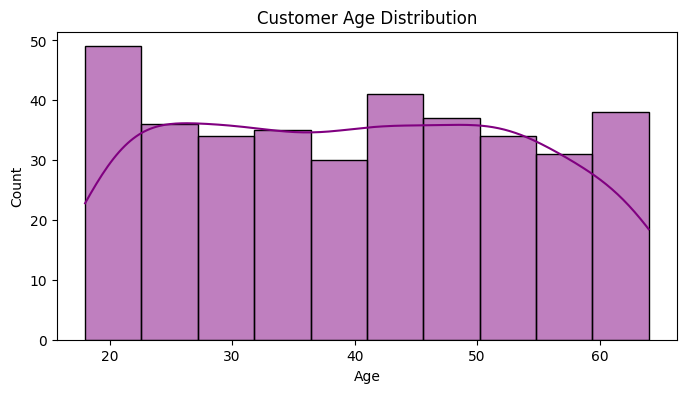

/tmp/ipykernel_2081/3026678143.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


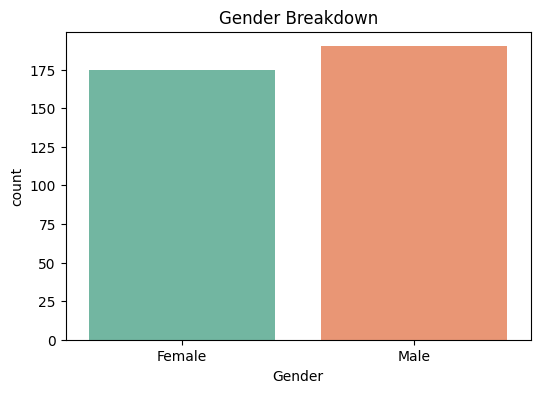

/tmp/ipykernel_2081/3026678143.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Total_Sales', data=category_revenue, palette='viridis')


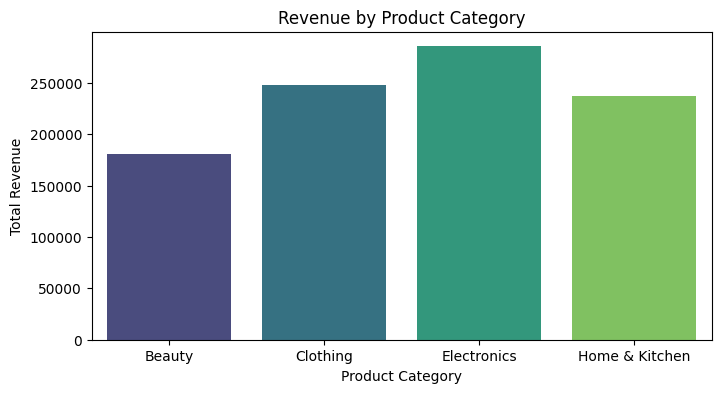

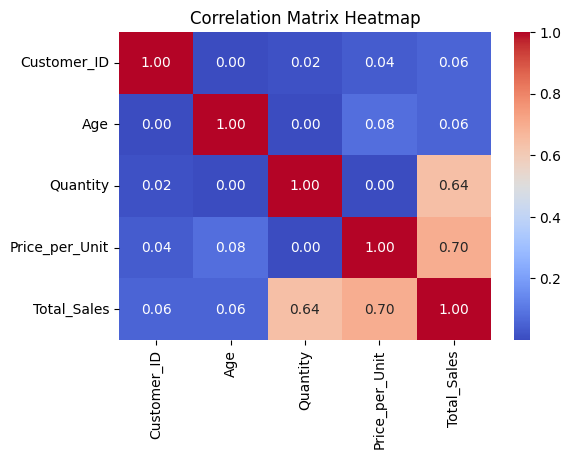

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
n_rows = len(dates)

data = {
    'Date': np.random.choice(dates, n_rows),
    'Customer_ID': np.random.randint(1000, 1100, n_rows),
    'Age': np.random.randint(18, 65, n_rows),
    'Gender': np.random.choice(['Male', 'Female'], n_rows),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty'], n_rows),
    'Quantity': np.random.randint(1, 5, n_rows),
    'Price_per_Unit': np.random.uniform(100, 2000, n_rows)
}

df = pd.DataFrame(data)
df['Total_Sales'] = df['Quantity'] * df['Price_per_Unit']

# Initial Inspection
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Column Data Types & Null Values ---")
print(df.info())

# 2. Descriptive Statistics
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 3. Time Series Analysis: Monthly Sales Trends
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o', color='b')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# 4. Customer Demographics Analysis
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=10, kde=True, color='purple')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Breakdown')
plt.show()

# 5. Product Analysis: Revenue by Product Category
category_revenue = df.groupby('Product_Category')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(x='Product_Category', y='Total_Sales', data=category_revenue, palette='viridis')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.show()

# 6. Heatmap: Correlation Matrix
plt.figure(figsize=(6, 4))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()